In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
df.shape

(1095, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [5]:
df["method"].notnull().sum()

21

In [6]:
df[df["method"].notnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
38,336022,2007/08,Delhi,2008-05-17,League,DPMD Jayawardene,Feroz Shah Kotla,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,Kings XI Punjab,runs,6.0,89.0,8.0,N,D/L,AV Jayaprakash,RE Koertzen
41,336025,2007/08,Kolkata,2008-05-18,League,M Ntini,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,Chennai Super Kings,runs,3.0,53.0,8.0,N,D/L,Asad Rauf,K Hariharan
60,392183,2009,Cape Town,2009-04-19,League,DL Vettori,Newlands,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,field,Delhi Daredevils,wickets,10.0,54.0,6.0,N,D/L,MR Benson,SD Ranade
63,392186,2009,Durban,2009-04-21,League,CH Gayle,Kingsmead,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,runs,11.0,69.0,9.2,N,D/L,DJ Harper,SD Ranade
89,392214,2009,Centurion,2009-05-07,League,ML Hayden,SuperSport Park,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,Chennai Super Kings,runs,12.0,187.0,18.0,N,D/L,DJ Harper,TH Wijewardene
192,501215,2011,Kochi,2011-04-18,League,BB McCullum,Nehru Stadium,Kochi Tuskers Kerala,Chennai Super Kings,Kochi Tuskers Kerala,field,Kochi Tuskers Kerala,wickets,7.0,135.0,17.0,N,D/L,K Hariharan,AL Hill
221,501245,2011,Kolkata,2011-05-07,League,Iqbal Abdulla,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,runs,10.0,52.0,10.0,N,D/L,Asad Rauf,PR Reiffel
231,501255,2011,Bangalore,2011-05-14,League,CH Gayle,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,4.0,102.0,13.0,N,D/L,RE Koertzen,RB Tiffin
429,733993,2014,Delhi,2014-05-10,League,DW Steyn,Feroz Shah Kotla,Delhi Daredevils,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,8.0,43.0,5.0,N,D/L,RM Deshpande,BNJ Oxenford
476,829743,2015,Visakhapatnam,2015-04-22,League,DA Warner,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,Sunrisers Hyderabad,runs,16.0,118.0,12.0,N,D/L,RK Illingworth,VA Kulkarni


## Most D/L results per season

In [7]:
DL_results = df.groupby("season").count()["method"].sort_values(ascending=False).head(5)

C:\Users\khans\AppData\Local\Temp\ipykernel_32420\3408495744.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=DL_results.values, y=DL_results.index, palette="vlag")


Text(0.5, 1.0, ' Most D/L results per saeson')

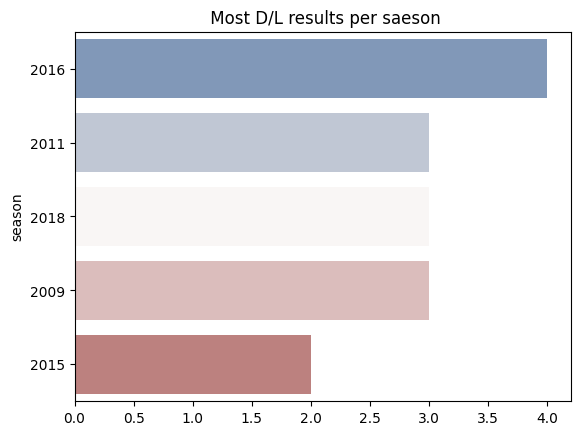

In [8]:
sns.barplot(x=DL_results.values, y=DL_results.index, palette="vlag")
plt.title(" Most D/L results per saeson")

## Season trends

In [9]:
matches=df.groupby("season").count()["id"].sort_values(ascending=False)

C:\Users\khans\AppData\Local\Temp\ipykernel_32420\958965226.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches.values, y=matches.index, palette="mako")


Text(0.5, 1.0, 'Most matches per season')

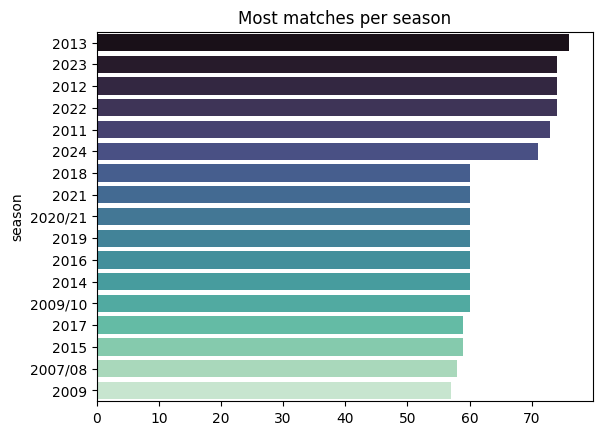

In [10]:
sns.barplot(x=matches.values, y=matches.index, palette="mako")
plt.title("Most matches per season")

In [11]:
venues = df["venue"].value_counts().head(10)

Text(0.5, 1.0, 'Top 10 venues')

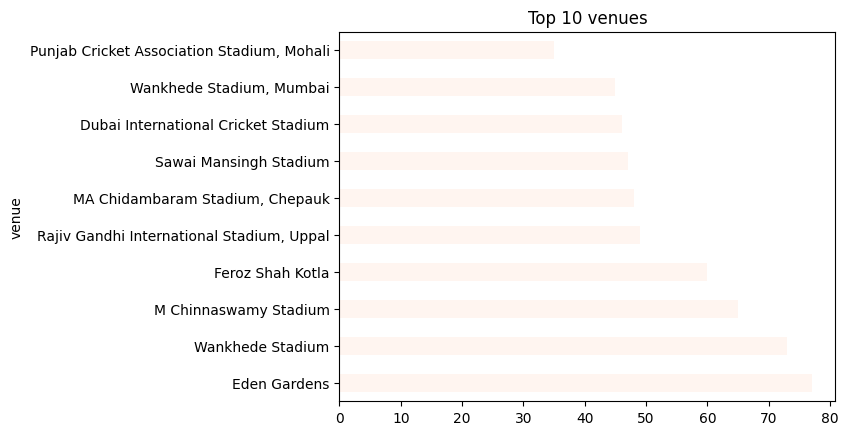

In [12]:
venues.plot(kind="barh",colormap="Reds")
plt.title("Top 10 venues")

In [13]:
toss=df["toss_decision"].value_counts()

<Axes: xlabel='toss_decision'>

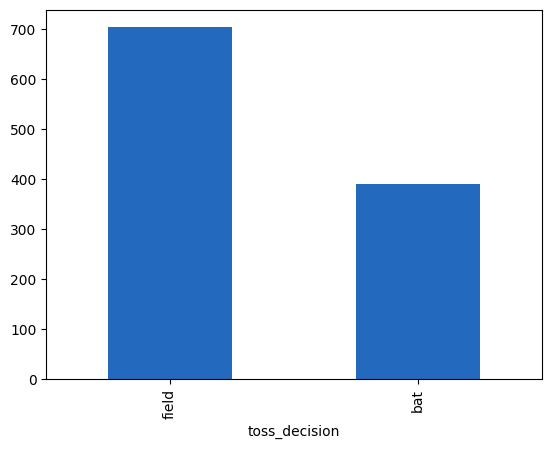

In [14]:
toss.plot(kind="bar",colormap="vlag")

## win_toss vs win_match (all seasons)

In [15]:
won=df[df["toss_winner"]==df["winner"]].count()["id"]
win_percentage= (won * 100)/df.shape[0]

In [16]:
win_percentage.round(3)

50.594

## Most Successful teams (all seasons)

In [17]:
winners=df["winner"].value_counts().head(5)

Text(0.5, 1.0, 'Top 5 teams with most wins')

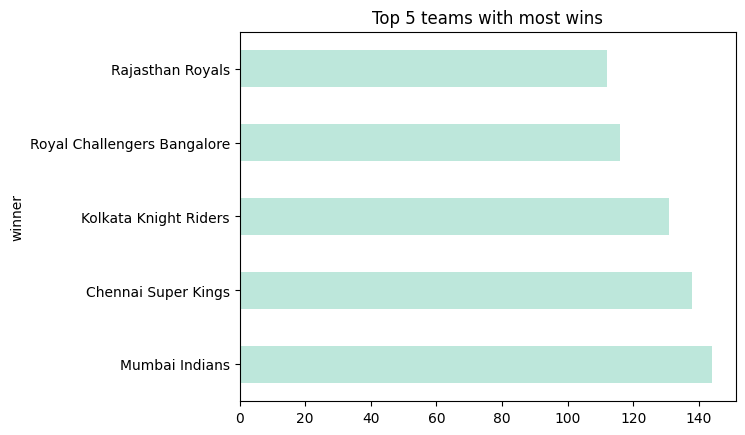

In [18]:
winners.plot(kind='barh', colormap="icefire")
plt.title("Top 5 teams with most wins")

In [19]:
res_type=df["result"].value_counts()

([<matplotlib.patches.Wedge at 0x1f76d8167a0>,
 [Text(-0.09613339396061713, 1.0957912075599132, 'wickets'),
  Text(0.03628689157184371, -1.0994013195826415, 'runs'),
  Text(1.097393350313619, -0.07568245957585214, 'tie'),
  Text(1.0998868237743198, -0.015778938102376395, 'no result')])

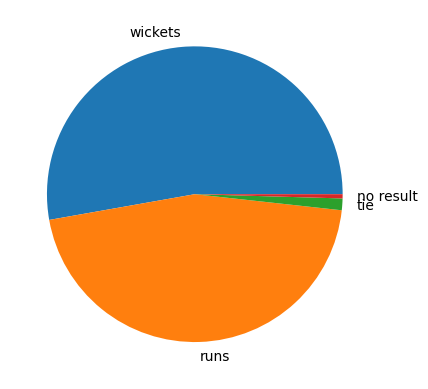

In [20]:
plt.pie(res_type.values,labels= res_type.index)

## result margin

In [21]:
df.groupby("season")["result_margin"].max()

season
2007/08    140.0
2009        92.0
2009/10     98.0
2011       111.0
2012        86.0
2013       130.0
2014        93.0
2015       138.0
2016       144.0
2017       146.0
2018       102.0
2019       118.0
2020/21     97.0
2021        86.0
2022        91.0
2023       112.0
2024       106.0
Name: result_margin, dtype: float64

In [22]:
df.groupby("season")["result_margin"].min()


season
2007/08    1.0
2009       1.0
2009/10    2.0
2011       2.0
2012       1.0
2013       2.0
2014       2.0
2015       1.0
2016       1.0
2017       1.0
2018       1.0
2019       1.0
2020/21    2.0
2021       1.0
2022       2.0
2023       1.0
2024       1.0
Name: result_margin, dtype: float64

In [23]:
df.groupby("season")["result_margin"].mean()

season
2007/08    15.965517
2009       16.857143
2009/10    19.762712
2011       18.930556
2012       16.229730
2013       19.837838
2014       14.728814
2015       17.821429
2016       15.333333
2017       17.103448
2018       14.350000
2019       15.210526
2020/21    22.589286
2021       13.576271
2022       16.972973
2023       19.246575
2024       17.873239
Name: result_margin, dtype: float64

In [24]:
df.groupby("season")["result_margin"].median()

season
2007/08    8.0
2009       7.5
2009/10    9.0
2011       8.5
2012       8.0
2013       8.0
2014       7.0
2015       8.5
2016       7.0
2017       7.5
2018       7.0
2019       7.0
2020/21    9.5
2021       7.0
2022       8.0
2023       7.0
2024       8.0
Name: result_margin, dtype: float64

C:\Users\khans\AppData\Local\Temp\ipykernel_32420\2286868622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'season', y = 'result_margin', data = df, palette='vlag')


<Axes: xlabel='season', ylabel='result_margin'>

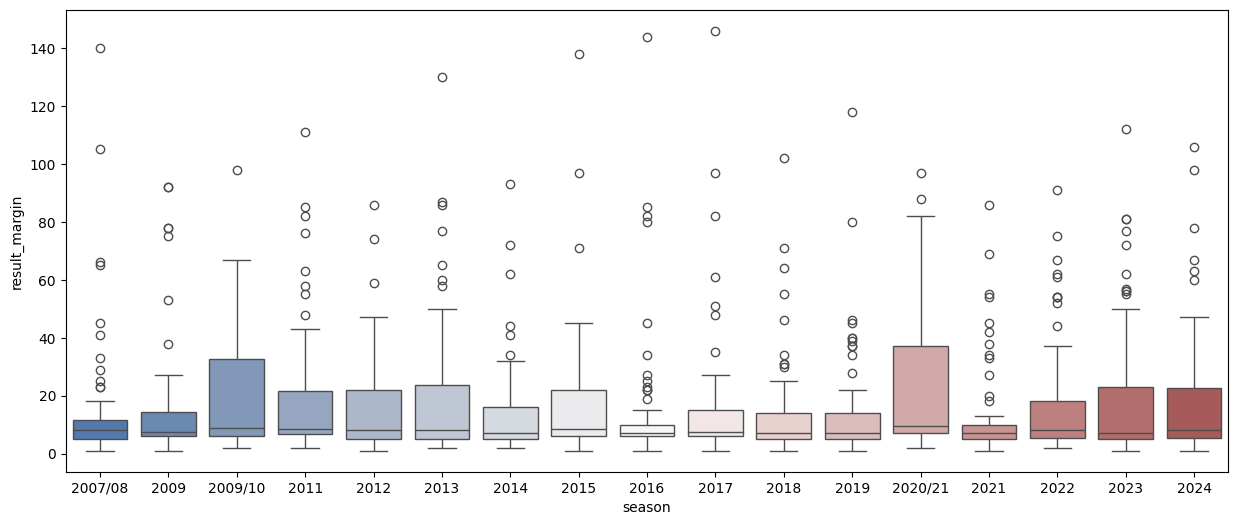

In [25]:
plt.figure(figsize=(15,6))
sns.boxplot(x = 'season', y = 'result_margin', data = df, palette='vlag')

In [26]:
avg_target=df.groupby("season")["target_runs"].mean()

<Axes: xlabel='season'>

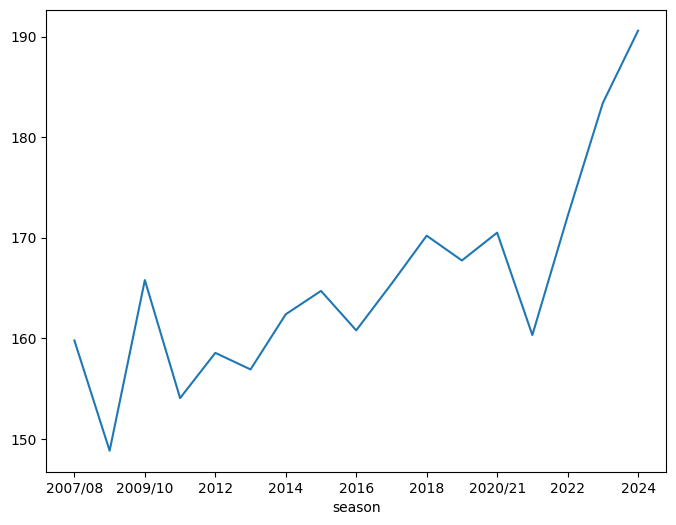

In [27]:
plt.figure(figsize=(8,6))
avg_target.plot(kind="line")

## Chasing vs Defending

In [28]:
result_type=df[["winner", "result"]].groupby("winner").value_counts()
result_type

winner                       result 
Chennai Super Kings          runs       71
                             wickets    67
Deccan Chargers              runs       18
                             wickets    11
Delhi Capitals               wickets    24
                             runs       21
                             tie         3
Delhi Daredevils             wickets    42
                             runs       25
Gujarat Lions                wickets    12
                             runs        1
Gujarat Titans               wickets    17
                             runs       11
Kings XI Punjab              wickets    45
                             runs       40
                             tie         3
Kochi Tuskers Kerala         wickets     4
                             runs        2
Kolkata Knight Riders        wickets    76
                             runs       54
                             tie         1
Lucknow Super Giants         runs       16
                 

In [29]:
res = result_type.reset_index()
print(res)
res.columns = ['winner', 'result', 'count']

# Pivot to wide format
df_pivot =res.pivot(index='winner', columns='result', values='count').fillna(0)


                         winner   result  count
0           Chennai Super Kings     runs     71
1           Chennai Super Kings  wickets     67
2               Deccan Chargers     runs     18
3               Deccan Chargers  wickets     11
4                Delhi Capitals  wickets     24
5                Delhi Capitals     runs     21
6                Delhi Capitals      tie      3
7              Delhi Daredevils  wickets     42
8              Delhi Daredevils     runs     25
9                 Gujarat Lions  wickets     12
10                Gujarat Lions     runs      1
11               Gujarat Titans  wickets     17
12               Gujarat Titans     runs     11
13              Kings XI Punjab  wickets     45
14              Kings XI Punjab     runs     40
15              Kings XI Punjab      tie      3
16         Kochi Tuskers Kerala  wickets      4
17         Kochi Tuskers Kerala     runs      2
18        Kolkata Knight Riders  wickets     76
19        Kolkata Knight Riders     runs

In [30]:
df_pivot

result,runs,tie,wickets
winner,,,
Chennai Super Kings,71.0,0.0,67.0
Deccan Chargers,18.0,0.0,11.0
Delhi Capitals,21.0,3.0,24.0
Delhi Daredevils,25.0,0.0,42.0
Gujarat Lions,1.0,0.0,12.0
Gujarat Titans,11.0,0.0,17.0
Kings XI Punjab,40.0,3.0,45.0
Kochi Tuskers Kerala,2.0,0.0,4.0
Kolkata Knight Riders,54.0,1.0,76.0


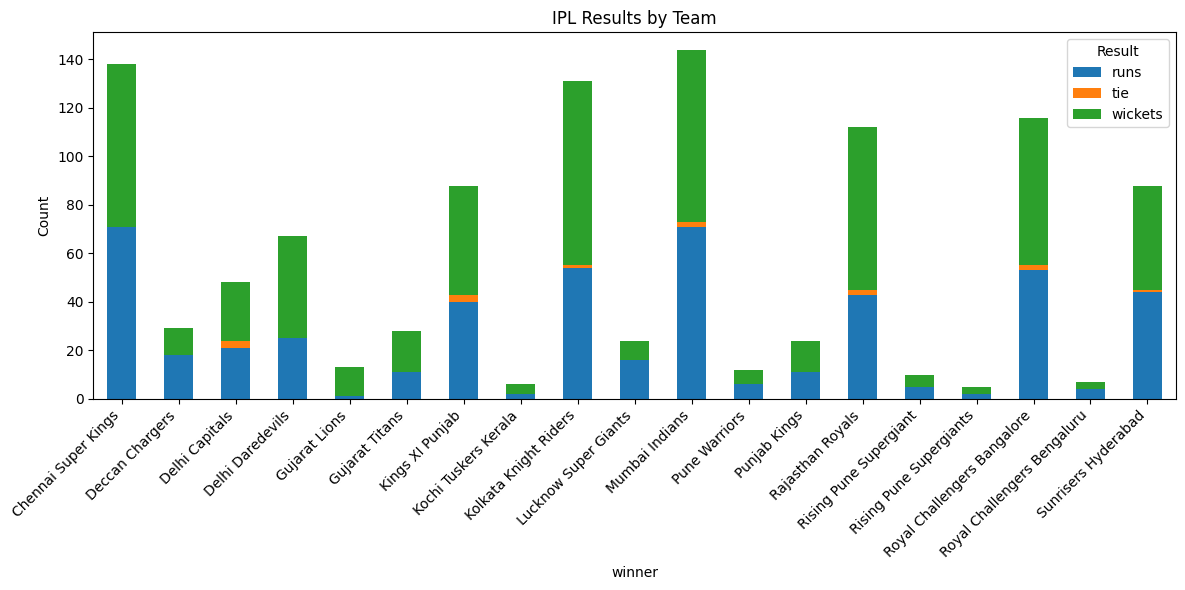

In [31]:
df_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.ylabel('Count')
plt.title('IPL Results by Team')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Result')
plt.tight_layout()
plt.show()

In [32]:
super_over=df.groupby("season")["super_over"].value_counts()
sup = super_over.reset_index()

In [33]:
sup.columns = ['season', 'super_over', 'count']

# Pivot to wide format
sup_pivot =sup.pivot(index='season', columns='super_over', values='count').fillna(0)

In [34]:
s_overs=sup_pivot["Y"].sort_values(ascending=False).head(5)

Text(0.5, 1.0, 'Super Overs per season')

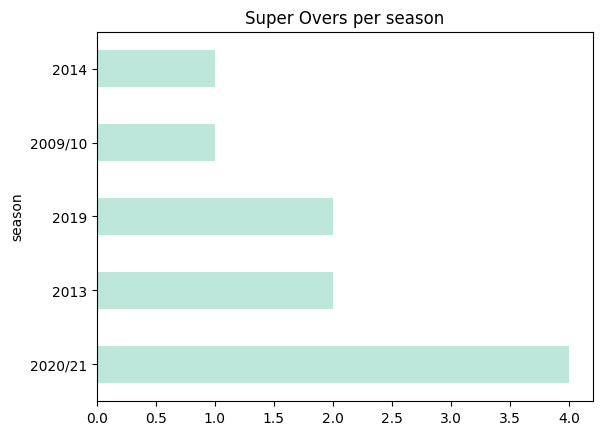

In [35]:
s_overs.plot(kind='barh', colormap="icefire")
plt.title("Super Overs per season")

In [36]:
mvp=df["player_of_match"].value_counts().head(15)

C:\Users\khans\AppData\Local\Temp\ipykernel_32420\2917923260.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mvp.values, y=mvp.index, palette="vlag")


Text(0.5, 1.0, ' Most MOTM')

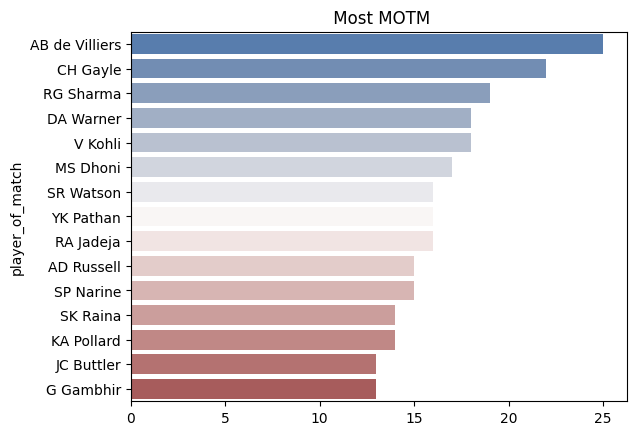

In [37]:
sns.barplot(x=mvp.values, y=mvp.index, palette="vlag")
plt.title(" Most MOTM")

In [38]:
champs=df[df["match_type"]== "Final"]["winner"].value_counts()


C:\Users\khans\AppData\Local\Temp\ipykernel_32420\2817065107.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=champs.values, y=champs.index, palette="Reds")


Text(0.5, 1.0, ' Most Successful teams')

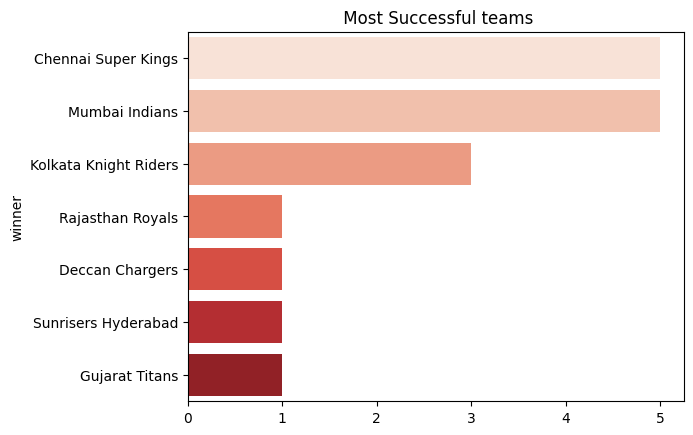

In [39]:
sns.barplot(x=champs.values, y=champs.index, palette="Reds")
plt.title(" Most Successful teams")